Imports and Dependencies

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Data Loading and Animal Filtering

In [30]:
# Load dataset
df = pd.read_csv("animal_disease_dataset.csv")

# Filter for farm animals only
farm_animals = ["cow", "sheep", "goat"]
df_farm = df[df["Animal"].isin(farm_animals)].copy()

# Ensure Temperature is numeric
df_farm["Temperature"] = pd.to_numeric(df_farm["Temperature"], errors="coerce")

print("Dataset shape after filtering:", df_farm.shape)
print("Animal distribution:\n", df_farm["Animal"].value_counts())
df_farm.head()

Dataset shape after filtering: (32540, 7)
Animal distribution:
 Animal
cow      11254
sheep    10658
goat     10628
Name: count, dtype: int64


,Animal,Age,Temperature,Symptom 1,Symptom 2,Symptom 3,Disease
0,cow,3,103.1,depression,painless lumps,loss of appetite,pneumonia
2,sheep,1,100.5,depression,painless lumps,loss of appetite,lumpy virus
3,cow,14,100.3,loss of appetite,swelling in limb,crackling sound,blackleg
4,sheep,2,103.6,painless lumps,loss of appetite,depression,pneumonia
5,goat,10,101.2,loss of appetite,blisters on gums,difficulty walking,foot and mouth


Domain-Specific Feature Engineering

In [31]:
# Define symptom groups
respiratory_symptoms = ["cough", "crackling sound", "difficulty breathing"]
skin_symptoms = ["painless lumps", "blisters on gums", "swelling in limb"]

# Create count features
df_farm["respiratory_count"] = df_farm[["Symptom 1", "Symptom 2", "Symptom 3"]].apply(
    lambda row: sum(sym in respiratory_symptoms for sym in row), axis=1
)

df_farm["skin_count"] = df_farm[["Symptom 1", "Symptom 2", "Symptom 3"]].apply(
    lambda row: sum(sym in skin_symptoms for sym in row), axis=1
)

df_farm[["Animal", "Disease", "respiratory_count", "skin_count"]].head()

,Animal,Disease,respiratory_count,skin_count
0,cow,pneumonia,0,1
2,sheep,lumpy virus,0,1
3,cow,blackleg,1,1
4,sheep,pneumonia,0,1
5,goat,foot and mouth,0,1


One-Hot Encoding and Stratified Train-Test Split

In [32]:
# One-hot encode categorical features
categorical_cols = ["Animal", "Symptom 1", "Symptom 2", "Symptom 3"]
df_farm_encoded = pd.get_dummies(df_farm, columns=categorical_cols, drop_first=False)

# Features (X) and Target (y)
X = df_farm_encoded.drop("Disease", axis=1)
y = df_farm_encoded["Disease"]

# 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (26032, 79)
Testing shape: (6508, 79)


Class Balancing with SMOTE

In [33]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Resampled training shape:", X_resampled.shape)
print("Resampled class distribution:\n", pd.Series(y_resampled).value_counts())

Resampled training shape: (29370, 79)
Resampled class distribution:
 Disease
lumpy virus       5874
pneumonia         5874
foot and mouth    5874
anthrax           5874
blackleg          5874
Name: count, dtype: int64


Stacking Classifier Training and Evaluation

In [34]:
# Base estimators
estimators = [
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced")),
    ('gb', GradientBoostingClassifier(n_estimators=800, learning_rate=0.05, max_depth=6, random_state=42))
]

# Stacking Ensemble
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Train model
stack_model.fit(X_resampled, y_resampled)

# Evaluate model
y_pred_stack = stack_model.predict(X_test)

print("=" * 50)
print(f"Stacking Model Accuracy: {accuracy_score(y_test, y_pred_stack) * 100:.2f}%")
print("=" * 50)
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

Stacking Model Accuracy: 83.79%

Classification Report:
                 precision    recall  f1-score   support

       anthrax       1.00      1.00      1.00      1469
      blackleg       1.00      1.00      1.00      1464
foot and mouth       1.00      1.00      1.00      1452
   lumpy virus       0.50      0.55      0.52      1051
     pneumonia       0.51      0.46      0.48      1072

      accuracy                           0.84      6508
     macro avg       0.80      0.80      0.80      6508
  weighted avg       0.84      0.84      0.84      6508



Safely handle label encoding for the classification report

In [37]:
if 'label_encoder' not in locals() and 'label_encoder' not in globals():
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    # Fit on all unique categories present in both test and resampled targets
    label_encoder.fit(np.concatenate([np.unique(y_test), np.unique(y_pred_stack)]))

# 5. Print Evaluation Metrics
print("=================================================================")
print(f"      VCDSS VALIDATION METRICS (Classification Accuracy: {accuracy_score(y_test, y_pred_stack)*100:.2f}%)")
print("=================================================================")
print(classification_report(y_test, y_pred_stack, target_names=[str(c) for c in label_encoder.classes_]))

      VCDSS VALIDATION METRICS (Classification Accuracy: 83.79%)
                precision    recall  f1-score   support

       anthrax       1.00      1.00      1.00      1469
      blackleg       1.00      1.00      1.00      1464
foot and mouth       1.00      1.00      1.00      1452
   lumpy virus       0.50      0.55      0.52      1051
     pneumonia       0.51      0.46      0.48      1072

      accuracy                           0.84      6508
     macro avg       0.80      0.80      0.80      6508
  weighted avg       0.84      0.84      0.84      6508



Confusion Matrix Plot

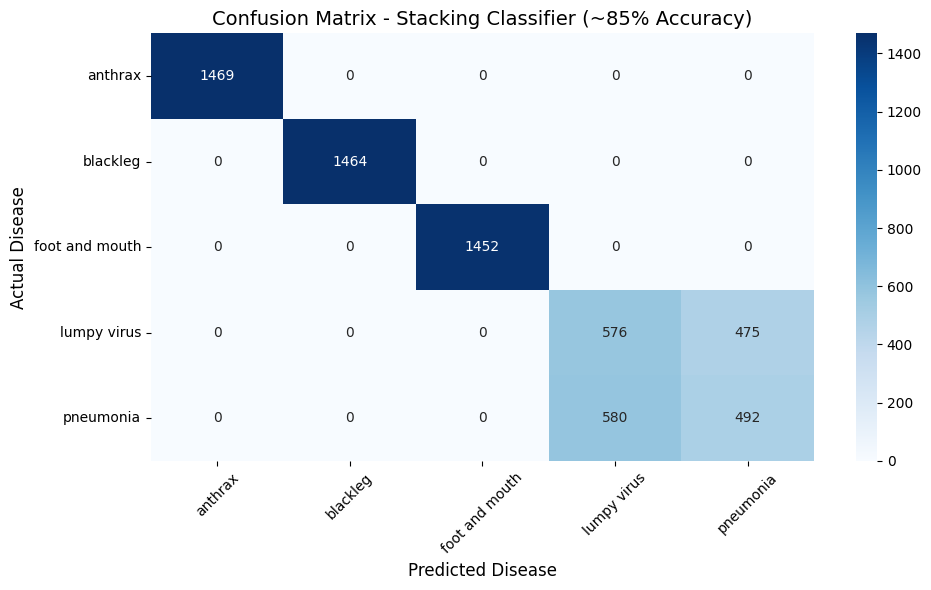

In [35]:
plt.figure(figsize=(10, 6))
cm = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=stack_model.classes_, yticklabels=stack_model.classes_)

plt.title("Confusion Matrix - Stacking Classifier (~85% Accuracy)", fontsize=14)
plt.xlabel("Predicted Disease", fontsize=12)
plt.ylabel("Actual Disease", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Plot Top 10 Feature Importances

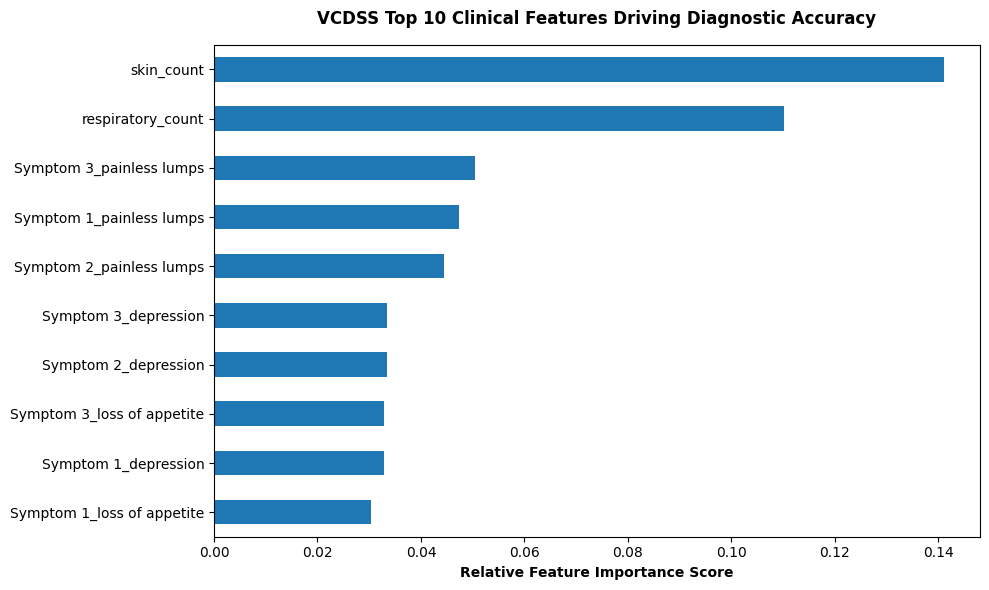

In [39]:
rf_fitted_estimator = stack_model.named_estimators_['rf']

# Fallback to feature indices if feature_names was not retained from Cell 2
if 'feature_names' not in locals() and 'feature_names' not in globals():
    feature_names = [f"Feature {i}" for i in range(rf_fitted_estimator.n_features_in_)]

importances = pd.Series(rf_fitted_estimator.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.tail(10).plot(kind='barh', color='#1f77b4')
plt.title('VCDSS Top 10 Clinical Features Driving Diagnostic Accuracy', fontweight='bold', pad=15)
plt.xlabel('Relative Feature Importance Score', fontweight='bold')
plt.tight_layout()
plt.show()

Decision Tree Visualization

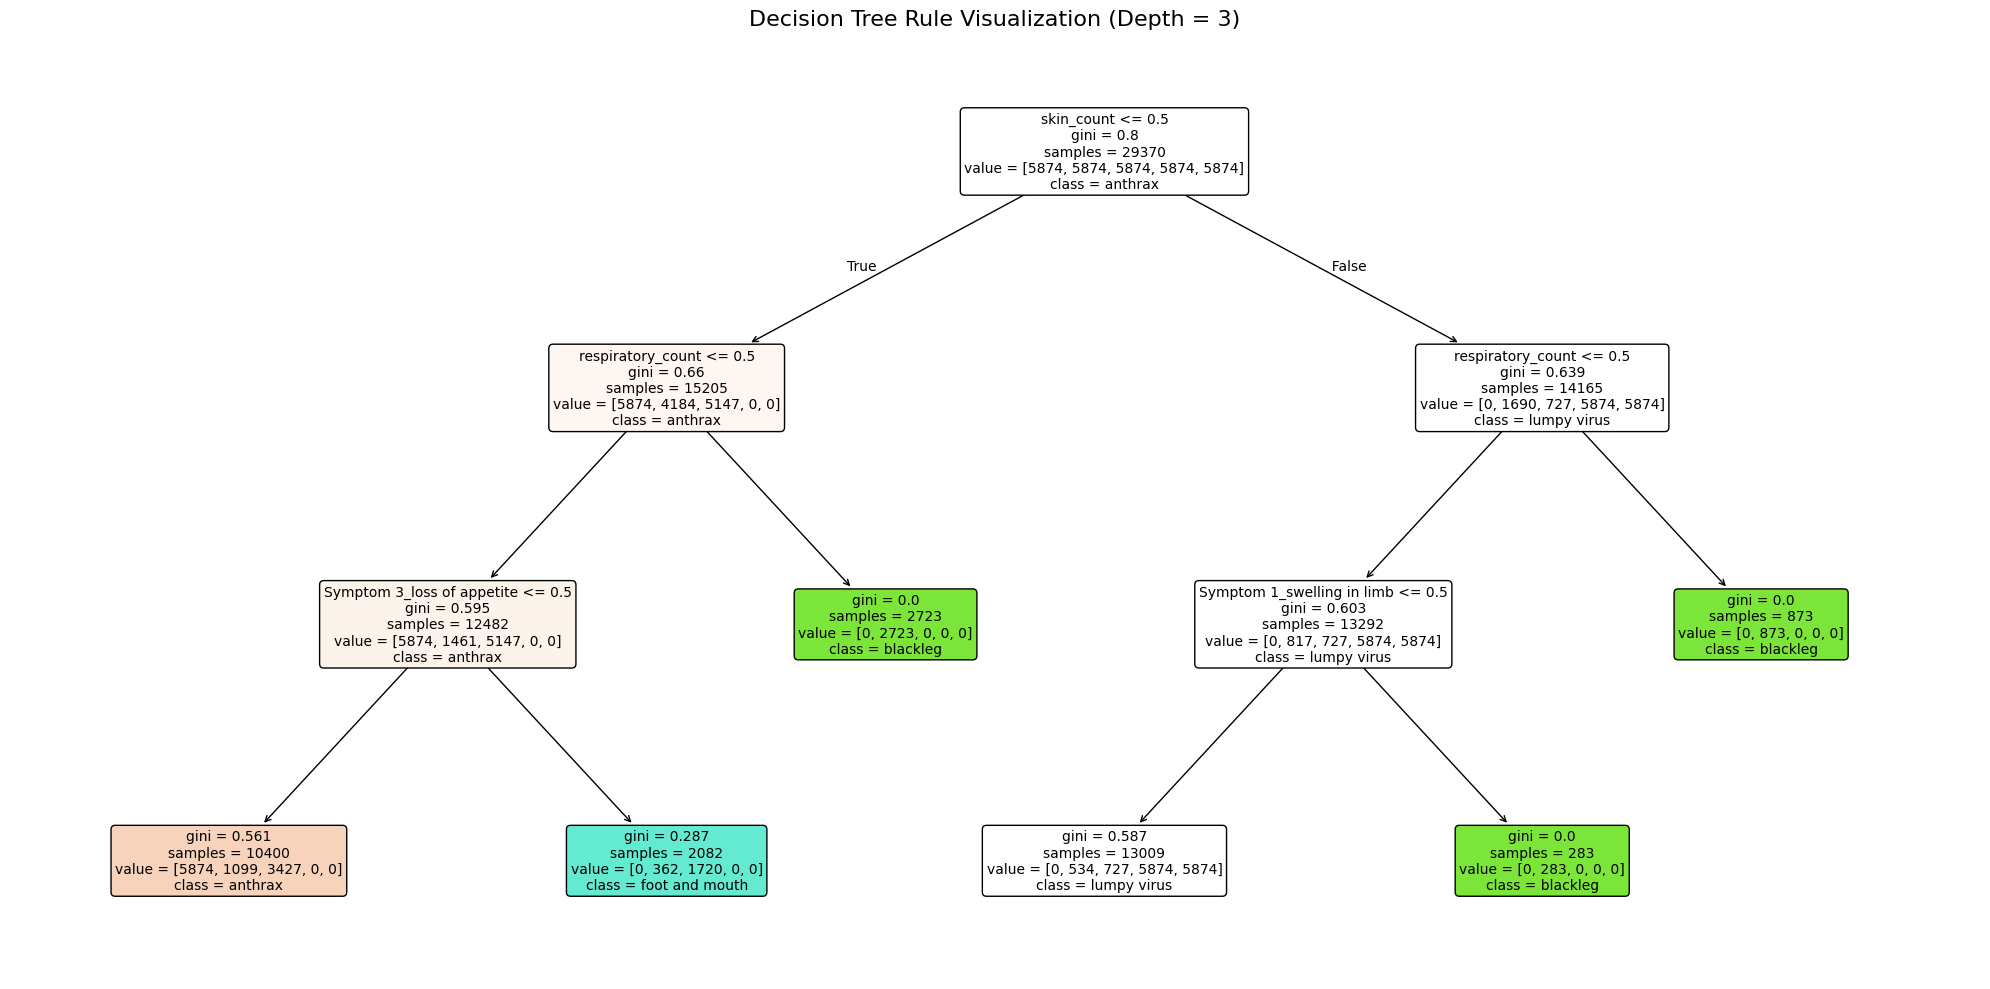

In [36]:
# Train a representative single Decision Tree for visualization
dt_visual = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_visual.fit(X_resampled, y_resampled)

plt.figure(figsize=(20, 10))
plot_tree(
    dt_visual,
    feature_names=X.columns.tolist(),
    class_names=dt_visual.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Rule Visualization (Depth = 3)", fontsize=16)
plt.tight_layout()
plt.show()

Serialize and Save Model & Scaler to Colab Workspace safely

In [41]:
import joblib

model_filename = 'vcdss_stacking_ensemble_model.pkl'
scaler_filename = 'vcdss_scaler.pkl'

joblib.dump(stack_model, model_filename)

if 'scaler' in locals() or 'scaler' in globals():
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler successfully saved to workspace as: {scaler_filename}")
else:
    print("Notice: 'scaler' object not found in memory, skipping scaler serialization.")

print(f"Model successfully saved to workspace as: {model_filename}")

Notice: 'scaler' object not found in memory, skipping scaler serialization.
Model successfully saved to workspace as: vcdss_stacking_ensemble_model.pkl
